# RealLift Demonstration: DoE - Design of Experiments

## 1. Installation

In [ ]:
# From GitHub
# %pip install git+https://github.com/RobertoJuniorWXYZ/RealLift.git
# or
# From PyPI
%pip install reallift

## 2. Generate Simulated Data

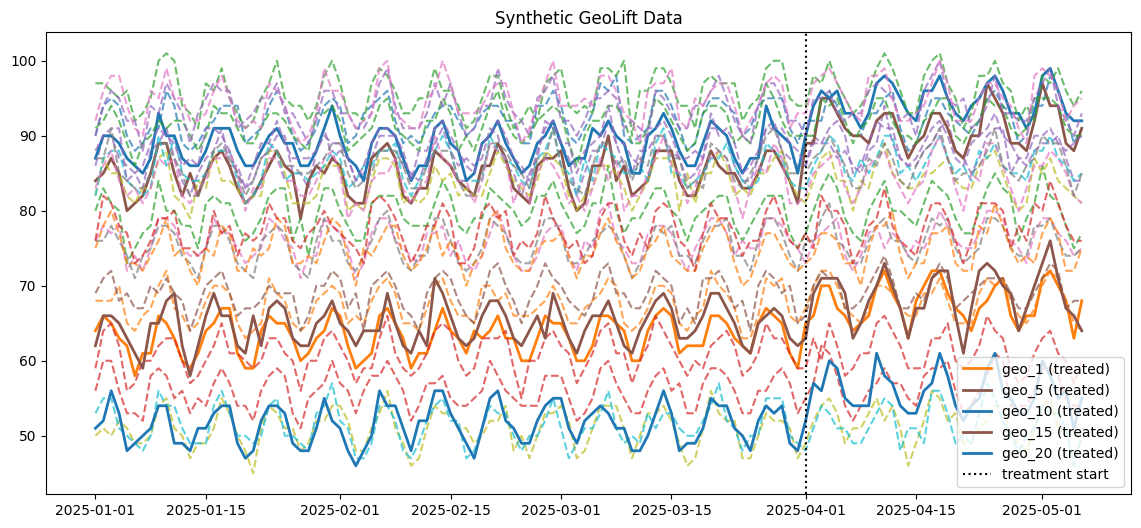

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from reallift import generate_geolift_data

# Parameters for simulation
file_pre_test = 'demo_geodata_pre_test.csv'
file_post_test = 'demo_geodata_post_test.csv'
start_date = "2025-01-01"
treatment_start = "2025-04-01"
end_date = pd.to_datetime(treatment_start) + pd.Timedelta(days=35)

df, df_pre, treated = generate_geolift_data(
    start_date = start_date,
    treatment_start = treatment_start,
    end_date = end_date,
    n_geos=27,
    treatment_geos=["geo_1","geo_5","geo_10","geo_15","geo_20"],
    lift=[0.05, 0.09],  # lift post test
    trend_slope=0.01,
    seasonality_amplitude=3,
    seasonality_period=7,
    noise_std=[1, 1.5],
    save_csv=True,
    file_name=file_post_test,
    pre_file_name=file_pre_test,
    base_value=[50, 100],
    as_integer=True,
    random_seed=42
)

## 3. Identifying Clusters
### Identifying Clusters (`find_best_geo_clusters`)
This function searches for the optimal combination of treatment and control geographies to minimize pre-treatment error and maximize the correlation between groups.
**Key Options:**
- `n_treatment`: Defines how many treatment groups to test (e.g., 2 for an A/B test across two cities).
- `fixed_treatment`: Allows you to force specific cities into the treatment group.
> [!TIP]
> **Recommendation:** Use at least 2 months of historical data to ensure the algorithm finds controls that accurately capture the treatment's seasonality.
**What it does:** It uses a regularized linear model to identify which controls best explain the treatment group's trend, returning a list of **Clusters** ready for individual analysis.


In [5]:
from reallift.geo.split import find_best_geo_clusters

clusters = find_best_geo_clusters(
    filepath=file_pre_test,
    date_col="date",
    n_treatment=5,
    fixed_treatment=["geo_1","geo_5","geo_10","geo_15","geo_20"]
)

Evaluating Combinations: 100%|██████████| 5/5 [00:00<00:00, 18.43it/s]



------------------------------------------------------------
FIXED TREATMENT ANALYSIS COMPLETED
Evaluating exclusive Synthetic Controls for the mandatory treatment units.
------------------------------------------------------------

=========== FINAL RESULTS (DONOR POOL & WEIGHTS) ===========

TEST CLUSTER 0 | Treatment: [geo_10] | Correlation: 0.8419 | Std Residual: 0.0152 | Synthetic Error Ratio: 0.0180
------------------------------------------------------------
Donor Pool:
  geo_12 (17.78%)     geo_14 (15.40%)     geo_22 (12.89%)     geo_19 (11.13%)     
  geo_16 (7.72%)      geo_17 (6.91%)      geo_25 (6.28%)      geo_24 (5.82%)      
  geo_2 (5.15%)       geo_0 (4.25%)       geo_6 (3.83%)       geo_18 (2.84%)      

TEST CLUSTER 1 | Treatment: [geo_5] | Correlation: 0.8059 | Std Residual: 0.0189 | Synthetic Error Ratio: 0.0234
------------------------------------------------------------
Donor Pool:
  geo_14 (32.02%)     geo_6 (8.87%)       geo_18 (8.75%)      geo_7 (8.71%)     

## 4. Validation

Cross-Validation (`validate_geo_groups`)
Performs a historical simulation (backtesting) to verify the model's ability to predict the treatment group's behavior *before* any actual intervention occurs.
**Key Options:**
- `n_folds`: Number of windows for **Time Series Cross-Validation**. We recommend using `n_folds=5` for better robustness.
- `train_test_split`: Defines the train/test ratio if you choose to use only 1 fold (static validation).
> [!IMPORTANT]
> **Success Metrics:** Aim for an **R2 > 0.8** in Cross-Validation. A large gap between Train R2 and OOF R2 (above 0.20) may indicate potential overfitting.
**What it does:** It splits historical data into training and testing windows. If the model can accurately predict the past, we gain high confidence that it will successfully capture the incremental effect during the real test.


=== GEO CLUSTER VALIDATION (Cluster 0) ===
Treatment: ['geo_10']
Control: ['geo_0', 'geo_2', 'geo_6', 'geo_12', 'geo_14', 'geo_16', 'geo_17', 'geo_18', 'geo_19', 'geo_22', 'geo_24', 'geo_25']

=== EVALUATING PERIOD ===
Start Date: 2025-01-01
End Date: 2025-03-31

--- TIME SERIES CROSS-VALIDATION (5 FOLDS) ---
Average Train R2: 0.8903 | Average OOF R2: 0.7821
Average Train MAPE: 0.0066 | Average OOF MAPE: 0.0103
Average Train WAPE: 0.0066 | Average OOF WAPE: 0.0103


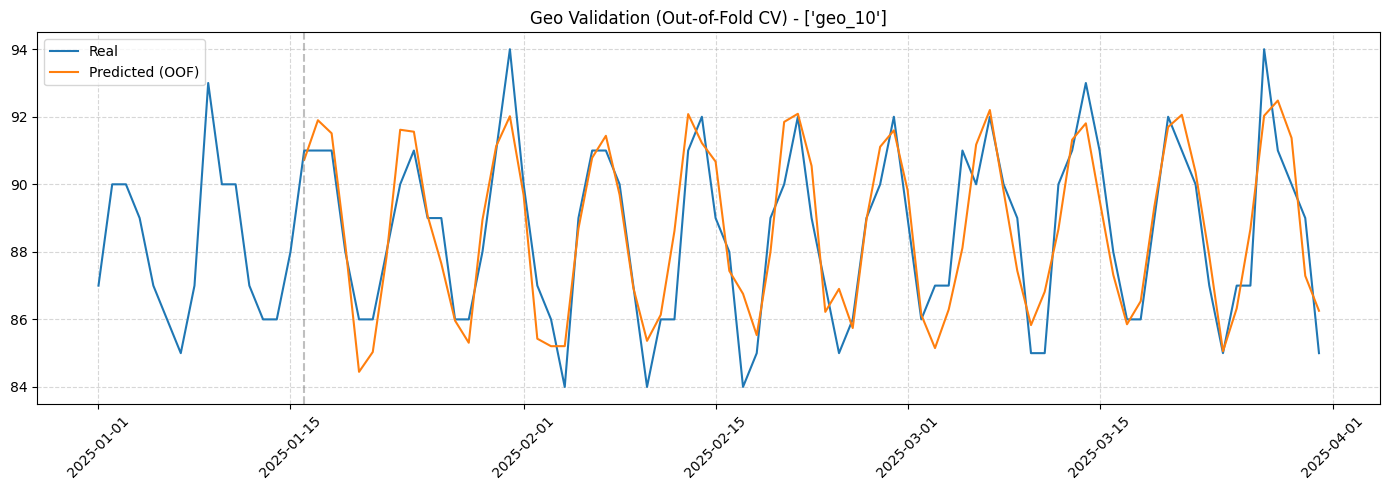


=== GEO CLUSTER VALIDATION (Cluster 1) ===
Treatment: ['geo_5']
Control: ['geo_0', 'geo_6', 'geo_7', 'geo_8', 'geo_12', 'geo_13', 'geo_14', 'geo_16', 'geo_17', 'geo_18', 'geo_22', 'geo_23', 'geo_25']

=== EVALUATING PERIOD ===
Start Date: 2025-01-01
End Date: 2025-03-31

--- TIME SERIES CROSS-VALIDATION (5 FOLDS) ---
Average Train R2: 0.8154 | Average OOF R2: 0.7814
Average Train MAPE: 0.0104 | Average OOF MAPE: 0.0114
Average Train WAPE: 0.0104 | Average OOF WAPE: 0.0113


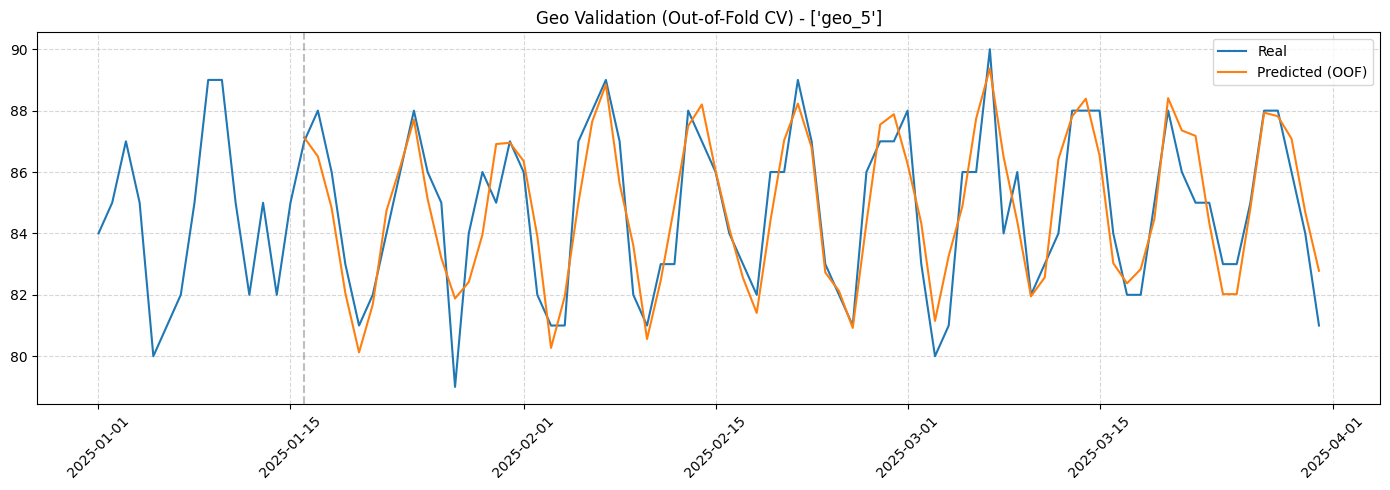


=== GEO CLUSTER VALIDATION (Cluster 2) ===
Treatment: ['geo_1']
Control: ['geo_2', 'geo_3', 'geo_7', 'geo_8', 'geo_14', 'geo_17', 'geo_18', 'geo_19', 'geo_21', 'geo_25']

=== EVALUATING PERIOD ===
Start Date: 2025-01-01
End Date: 2025-03-31

--- TIME SERIES CROSS-VALIDATION (5 FOLDS) ---
Average Train R2: 0.8170 | Average OOF R2: 0.6787
Average Train MAPE: 0.0143 | Average OOF MAPE: 0.0174
Average Train WAPE: 0.0142 | Average OOF WAPE: 0.0173


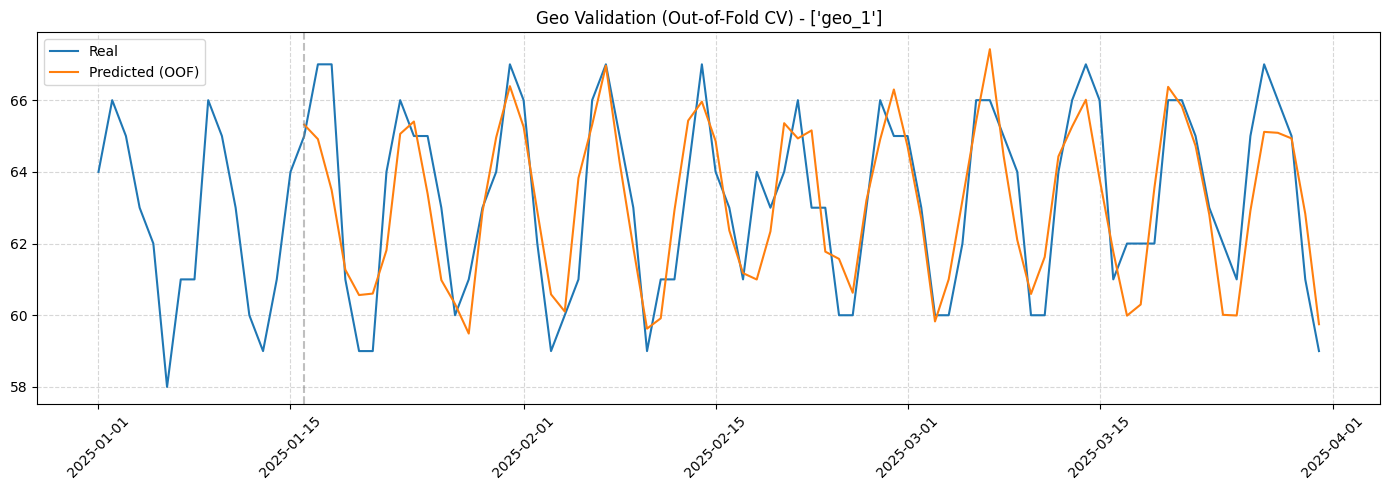


=== GEO CLUSTER VALIDATION (Cluster 3) ===
Treatment: ['geo_20']
Control: ['geo_3', 'geo_7', 'geo_11', 'geo_16', 'geo_21']

=== EVALUATING PERIOD ===
Start Date: 2025-01-01
End Date: 2025-03-31

--- TIME SERIES CROSS-VALIDATION (5 FOLDS) ---
Average Train R2: 0.7263 | Average OOF R2: 0.6846
Average Train MAPE: 0.0219 | Average OOF MAPE: 0.0240
Average Train WAPE: 0.0218 | Average OOF WAPE: 0.0240


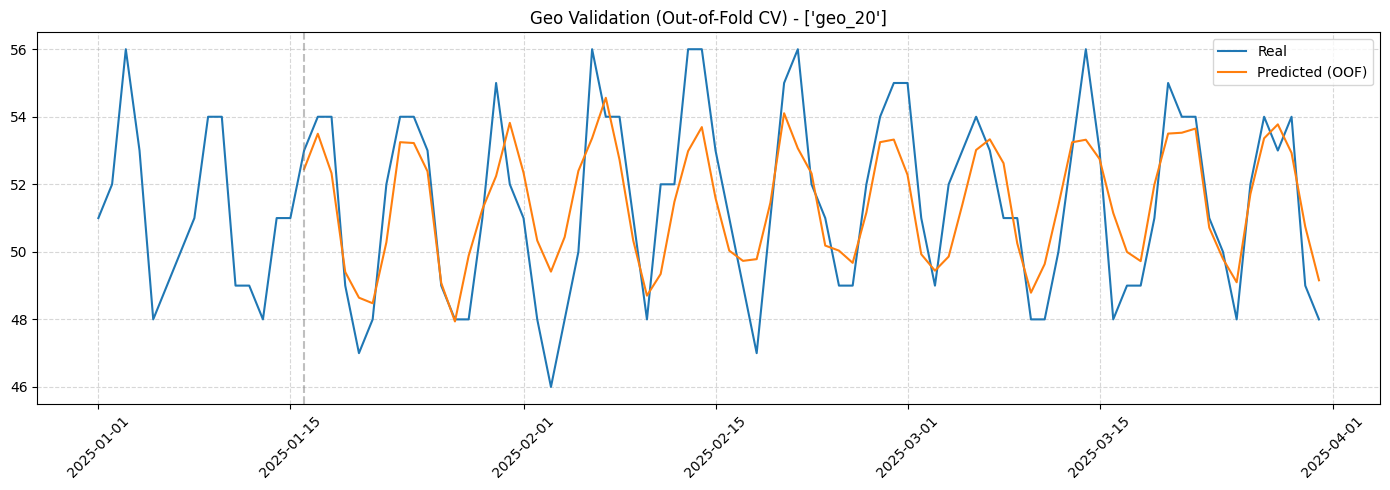


=== GEO CLUSTER VALIDATION (Cluster 4) ===
Treatment: ['geo_15']
Control: ['geo_7', 'geo_11', 'geo_13', 'geo_16', 'geo_19', 'geo_21', 'geo_24']

=== EVALUATING PERIOD ===
Start Date: 2025-01-01
End Date: 2025-03-31

--- TIME SERIES CROSS-VALIDATION (5 FOLDS) ---
Average Train R2: 0.7042 | Average OOF R2: 0.6852
Average Train MAPE: 0.0191 | Average OOF MAPE: 0.0172
Average Train WAPE: 0.0191 | Average OOF WAPE: 0.0174


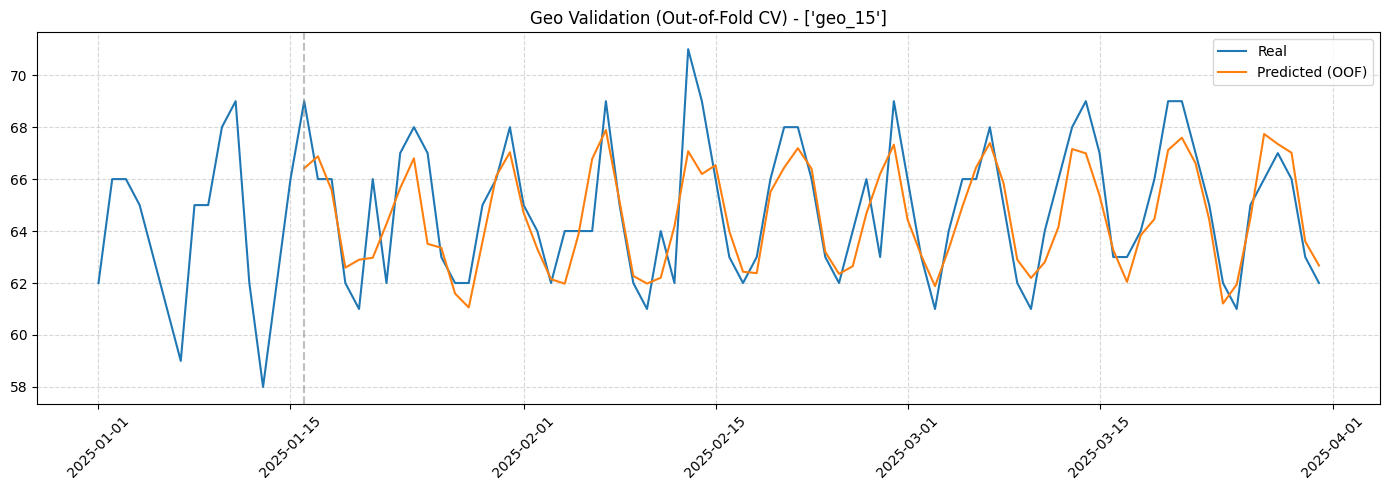

In [6]:
from reallift.geo.validation import validate_geo_groups

validation = validate_geo_groups(
    filepath=file_pre_test,
    date_col="date",
    splits=clusters,
    n_folds=5,
    plot=True,
    export_csv=False,
)

## Estimate Duration
### Duration Estimation (`estimate_duration`)
Calculates the minimum time required for the experiment to have enough statistical power to detect the desired impact (Lift).
**Key Options:**
- `mde`: Minimum Detectable Effect (e.g., 0.015 for 1.5%). This is the smallest impact you wish to detect with confidence.
- `power_target`: Statistical power target (default 0.8 or 80%).
- `max_days`: Limit of days for the duration simulation.
> [!NOTE]
> **Recommendation:** If the estimated duration is too long (> 6 weeks), try slightly increasing the MDE or looking for a cluster with higher correlation in step 6.1.
**What it does:** It estimates the historical residual error variance and applies power analysis to determine the sample size (days) needed to distinguish signal from noise.

In [7]:
from reallift.geo.duration import estimate_duration

for i, cluster in enumerate(clusters):
    summary = estimate_duration(
        filepath=file_pre_test,
        date_col="date",
        treatment_geo=cluster["treatment"][0],
        control_geos=cluster["control"],
        mde=0.015,
        max_days=[21, 60],
        cluster_idx=i
    )


=== GEO DURATION ESTIMATION (Cluster 0) ===
Treatment: geo_10
Control: ['geo_0', 'geo_2', 'geo_6', 'geo_12', 'geo_14', 'geo_16', 'geo_17', 'geo_18', 'geo_19', 'geo_22', 'geo_24', 'geo_25']

=== EVALUATING PERIOD ===
Start Date: 2025-01-01
End Date: 2025-03-31

=== REGRESSION STATISTICS ===
Mean: 88.53
Std Residual: 0.0152
R-Squared: 0.7093
Correlation: 0.920

=== MDE ===
MDE: 1.50%
Effect absolute: 1.33
Effect percent real: 1.50%

=== RESULT ===
✔ Min duration: 21 days
✔ Power: 99.44%

=== GEO DURATION ESTIMATION (Cluster 1) ===
Treatment: geo_5
Control: ['geo_0', 'geo_6', 'geo_7', 'geo_8', 'geo_12', 'geo_13', 'geo_14', 'geo_16', 'geo_17', 'geo_18', 'geo_22', 'geo_23', 'geo_25']

=== EVALUATING PERIOD ===
Start Date: 2025-01-01
End Date: 2025-03-31

=== REGRESSION STATISTICS ===
Mean: 84.77
Std Residual: 0.0189
R-Squared: 0.6495
Correlation: 0.894

=== MDE ===
MDE: 1.50%
Effect absolute: 1.27
Effect percent real: 1.50%

=== RESULT ===
✔ Min duration: 21 days
✔ Power: 95.08%

=== GEO D

## 5. Running the Experiment (Synthetic Control & Placebo Tests)

Intervention Measurement (`run_synthetic_control` & `run_placebo_tests`)
Evaluates the actual post-intervention effect by creating a "Synthetic Twin" of the treated regions and mathematically comparing it to the real treatment behavior. It then runs Placebo Tests to ensure the observed lift is statistically significant and not just random variance.

**Key Options:**
- `treatment_start_date`: The exact date the marketing intervention began. Data strictly *on or after* this date is used to calculate the Lift.
- `observed_lift`: Passed directly from the synthetic output into the Placebo tester to evaluate statistical robustness against false positives.
- `plot`: When True, generates rich graphical diagnostics of the synthetic baseline fit and the placebo distribution curve.

> [!IMPORTANT]
> **Success Metrics:** 
> - **Synthetic CI:** The 95% Bootstrap Confidence Interval for the total incremental lift should **not** cross zero.
> - **Placebo P-Value:** Aim for a **p-value < 0.10** (or 0.05). This confirms the intervention effect is significantly stronger than the natural noise of random untreated regions acting as fake interventions.

**What it does:** 
First, the **Convex Optimizer** generates the Synthetic Twin by precisely weighing the selected optimal control regions, and calculates the true Lift (Incremental impact). Afterwards, the **Placebo pipeline** rotates the "treatment" status entirely across untreated control states to map the background noise (null distribution) and definitively validate your actual campaign's statistical significance.



=== GEO SYNTHETIC CONTROL (Cluster 0) ===

Weights:
geo_0: 0.0425
geo_2: 0.0515
geo_6: 0.0383
geo_12: 0.1778
geo_14: 0.1540
geo_16: 0.0772
geo_17: 0.0691
geo_18: 0.0284
geo_19: 0.1113
geo_22: 0.1289
geo_24: 0.0582
geo_25: 0.0628

Treatment period:
Start: 2025-04-01
End: 2025-05-06
Duration: 36 days

Mean lift (abs): 5.36
Mean lift (%): 6.02 %
Total lift: 192.84

=== SIGNIFICANCE (Cluster 0) ===

T-Test:
t-stat: 27.178
p-value: 0.0000

=== BOOTSTRAP TESTS SUMMARY (Cluster 0) ===
Total lift (abs): 192.84
95% CI (abs): [179.38, 206.50]
Total lift (%): 6.01%
95% CI (%): [5.57%, 6.46%]
p-value (bootstrap): 0.0000
✔ Lift statistically significant (CI does not cross 0)


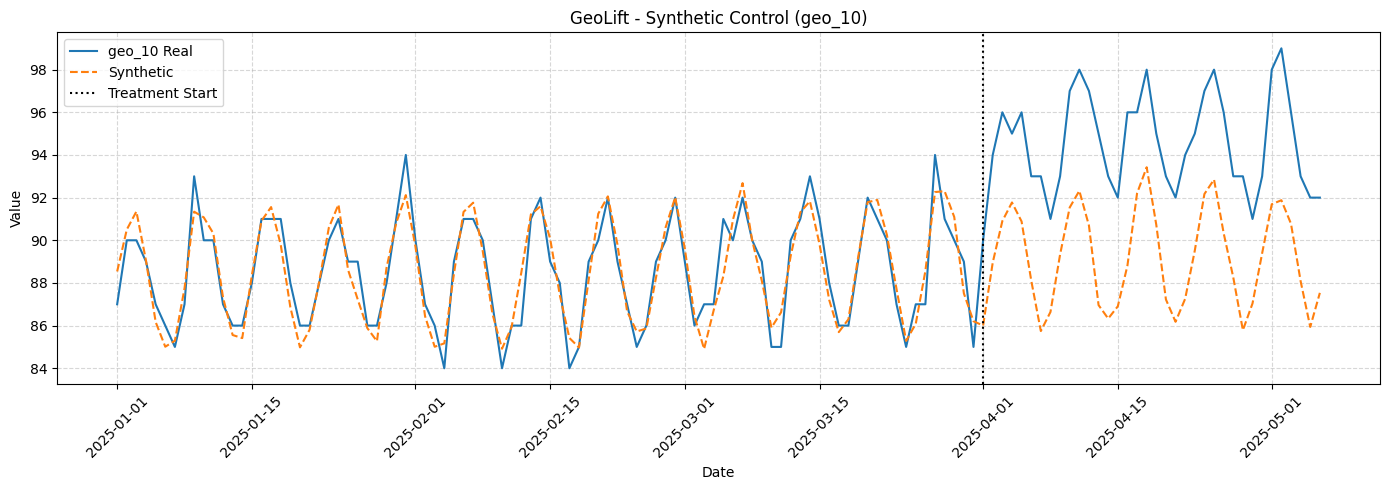

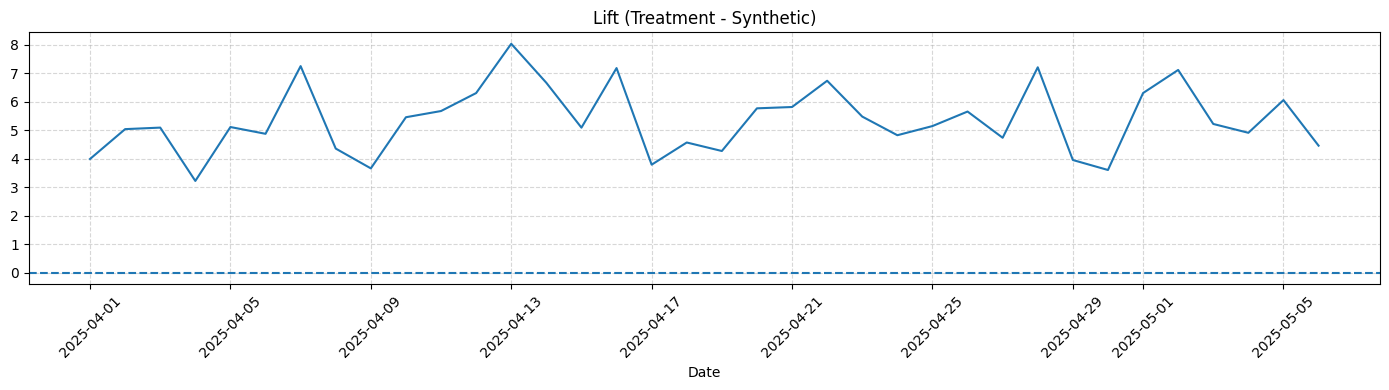

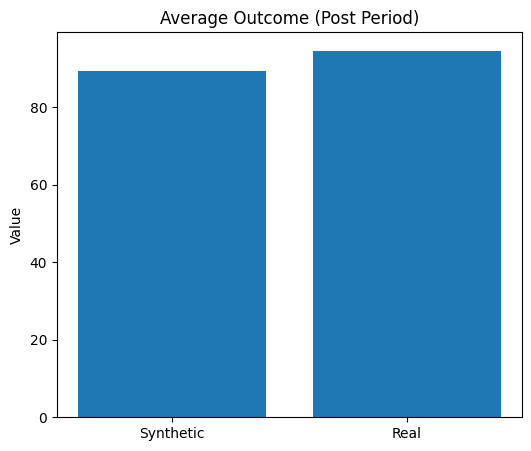

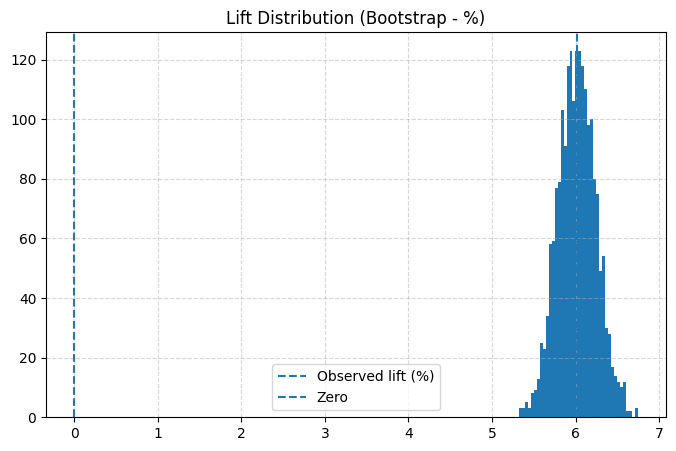


=== GEO PLACEBO TESTS (Cluster 0) ===
Number of placebo tests: 10
Average placebo lift (noise): 0.0134
Observed treatment lift: 5.3567
P-value (placebo): 0.0000
✔ High confidence: Observed lift is significantly higher than random placebos.


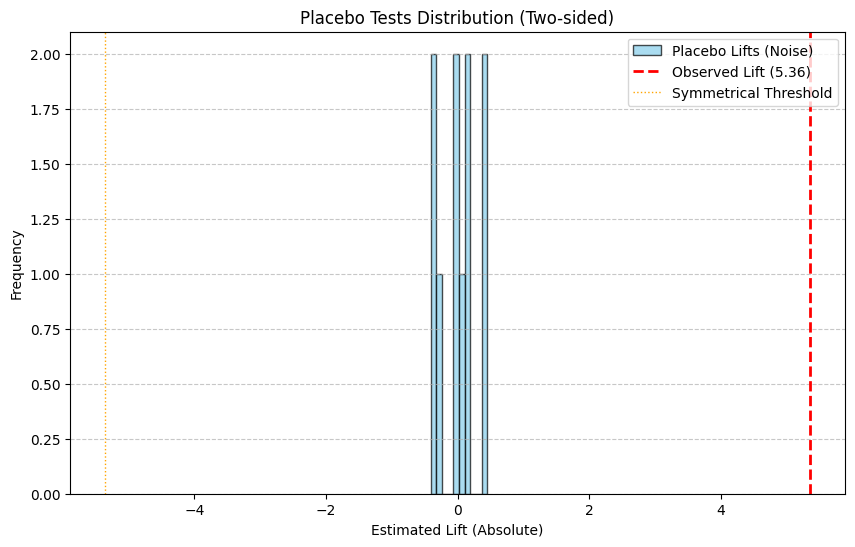


=== GEO SYNTHETIC CONTROL (Cluster 1) ===

Weights:
geo_0: 0.0176
geo_6: 0.0887
geo_7: 0.0871
geo_8: 0.0642
geo_12: 0.0812
geo_13: 0.0445
geo_14: 0.3202
geo_16: 0.0240
geo_17: 0.0697
geo_18: 0.0875
geo_22: 0.0265
geo_23: 0.0193
geo_25: 0.0695

Treatment period:
Start: 2025-04-01
End: 2025-05-06
Duration: 36 days

Mean lift (abs): 5.74
Mean lift (%): 6.72 %
Total lift: 206.68

=== SIGNIFICANCE (Cluster 1) ===

T-Test:
t-stat: 22.708
p-value: 0.0000

=== BOOTSTRAP TESTS SUMMARY (Cluster 1) ===
Total lift (abs): 206.68
95% CI (abs): [189.59, 223.45]
Total lift (%): 6.72%
95% CI (%): [6.16%, 7.27%]
p-value (bootstrap): 0.0000
✔ Lift statistically significant (CI does not cross 0)


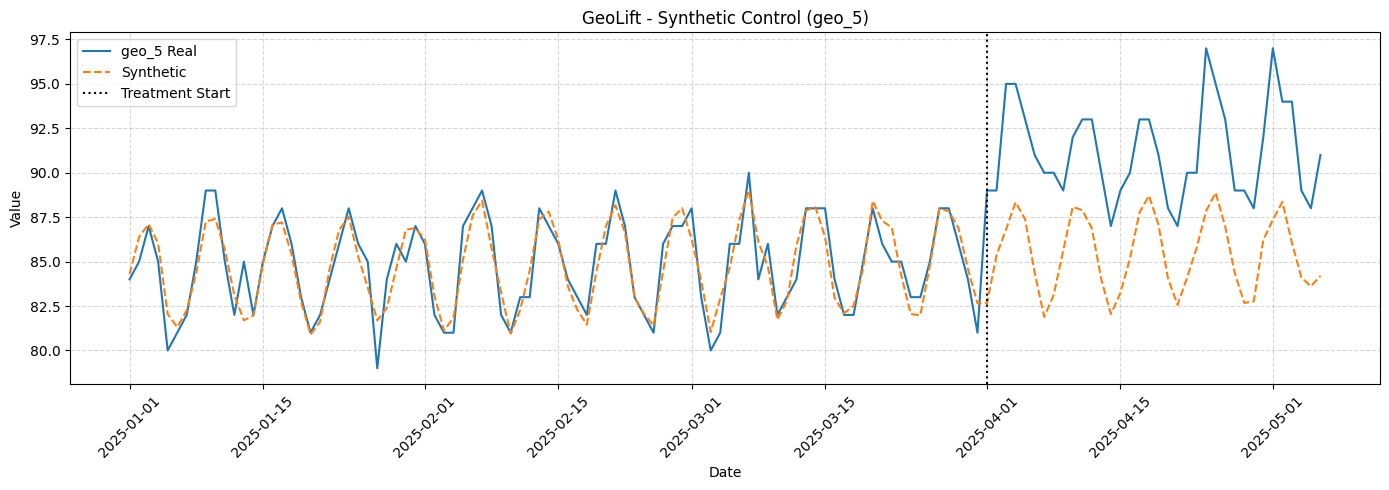

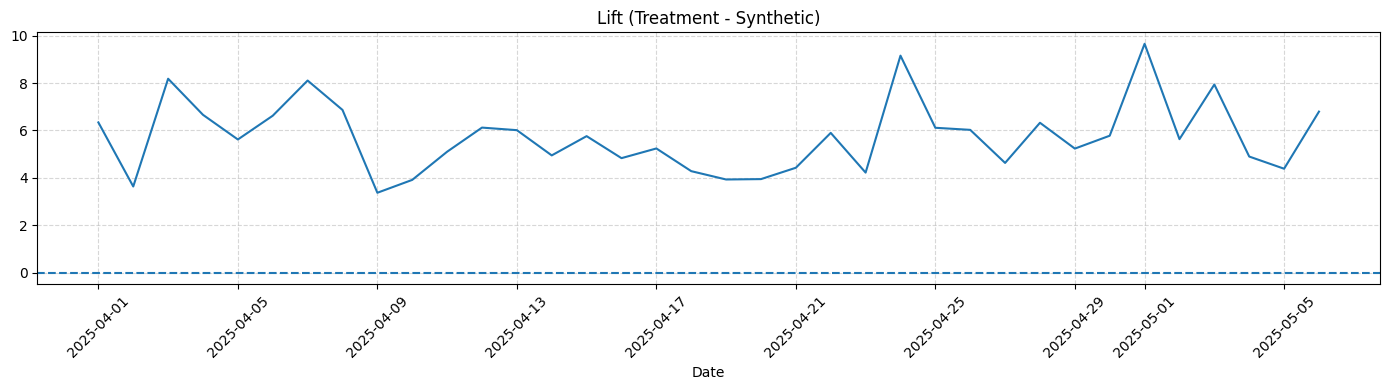

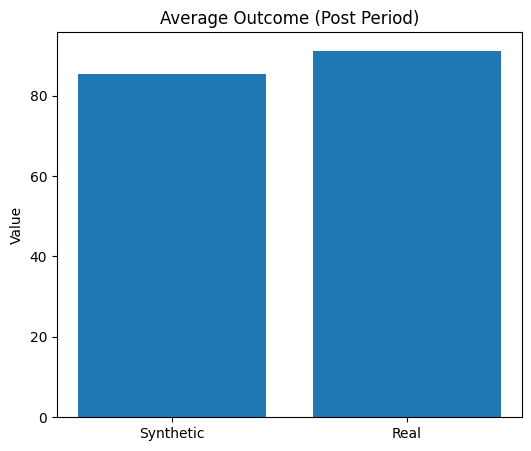

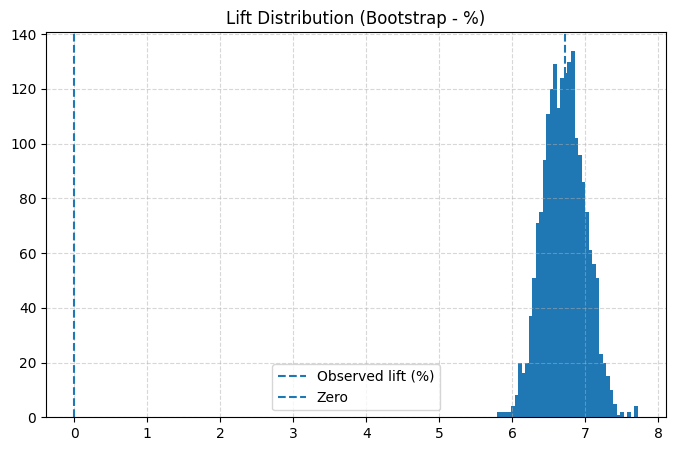


=== GEO PLACEBO TESTS (Cluster 1) ===
Number of placebo tests: 10
Average placebo lift (noise): -0.0319
Observed treatment lift: 5.7411
P-value (placebo): 0.0000
✔ High confidence: Observed lift is significantly higher than random placebos.


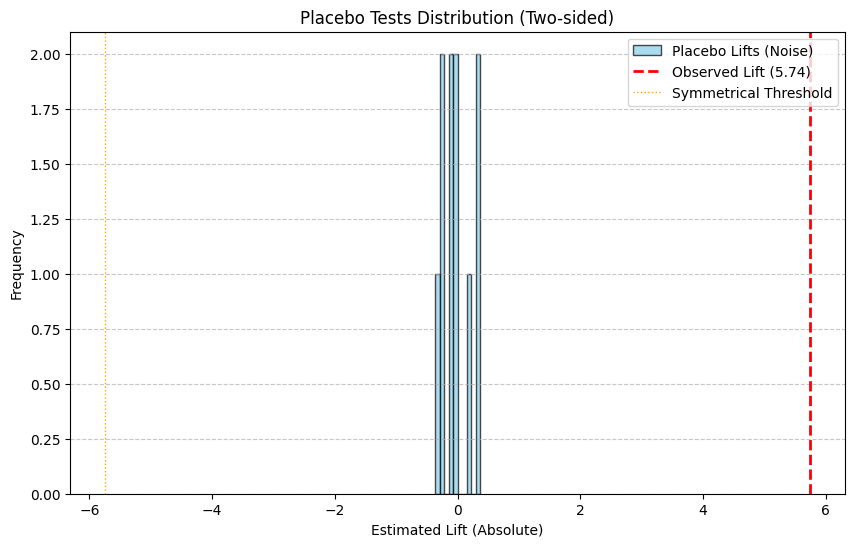


=== GEO SYNTHETIC CONTROL (Cluster 2) ===

Weights:
geo_2: 0.1547
geo_3: 0.0520
geo_7: 0.1689
geo_8: 0.1431
geo_14: 0.0104
geo_17: 0.1074
geo_18: 0.2307
geo_19: 0.0622
geo_21: 0.0121
geo_25: 0.0585

Treatment period:
Start: 2025-04-01
End: 2025-05-06
Duration: 36 days

Mean lift (abs): 3.94
Mean lift (%): 6.18 %
Total lift: 141.96

=== SIGNIFICANCE (Cluster 2) ===

T-Test:
t-stat: 16.642
p-value: 0.0000

=== BOOTSTRAP TESTS SUMMARY (Cluster 2) ===
Total lift (abs): 141.96
95% CI (abs): [125.76, 158.19]
Total lift (%): 6.18%
95% CI (%): [5.50%, 6.88%]
p-value (bootstrap): 0.0000
✔ Lift statistically significant (CI does not cross 0)


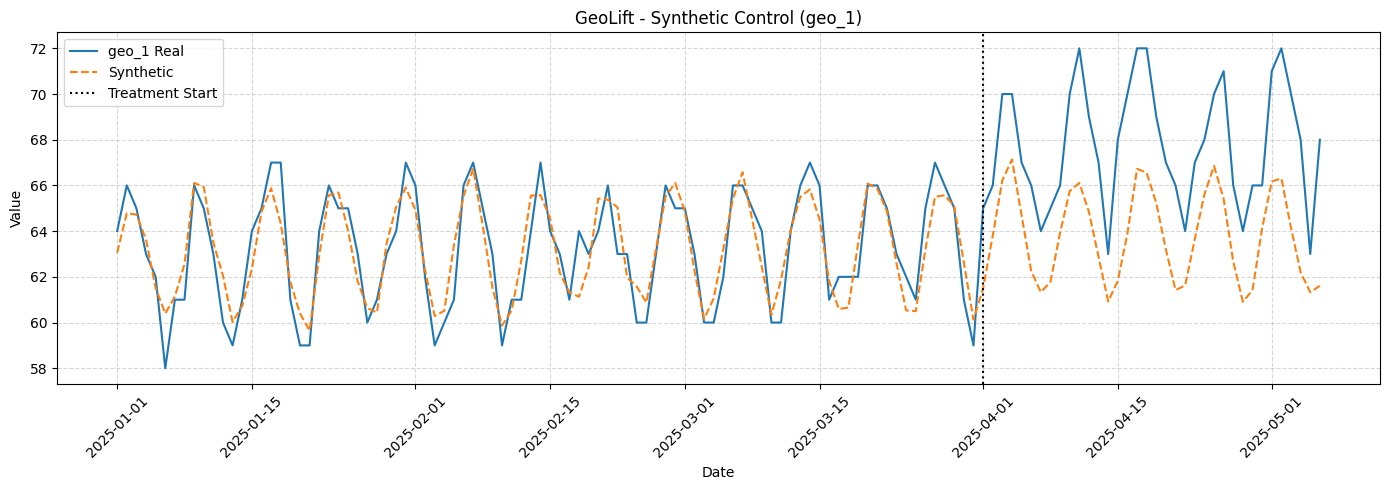

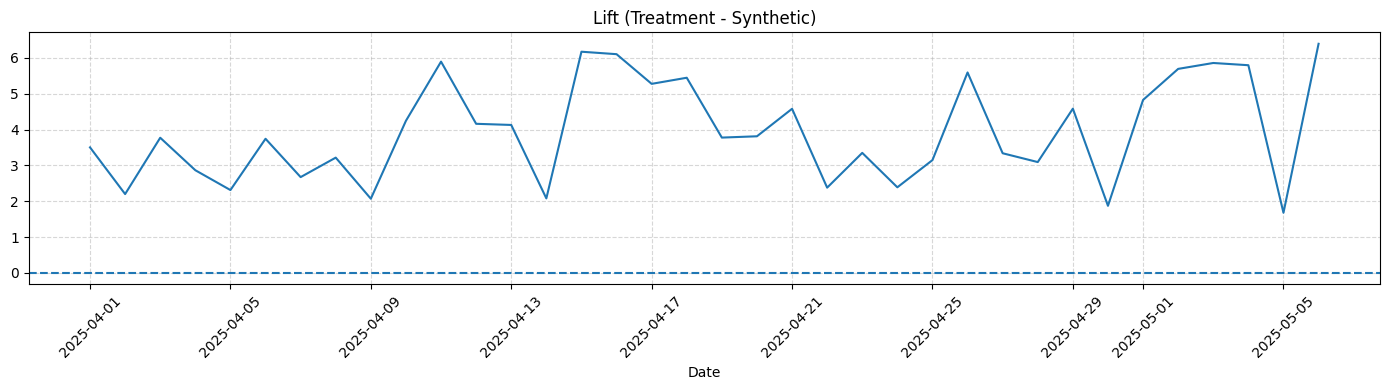

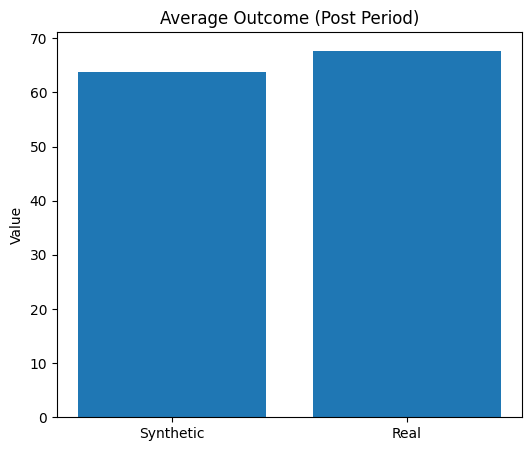

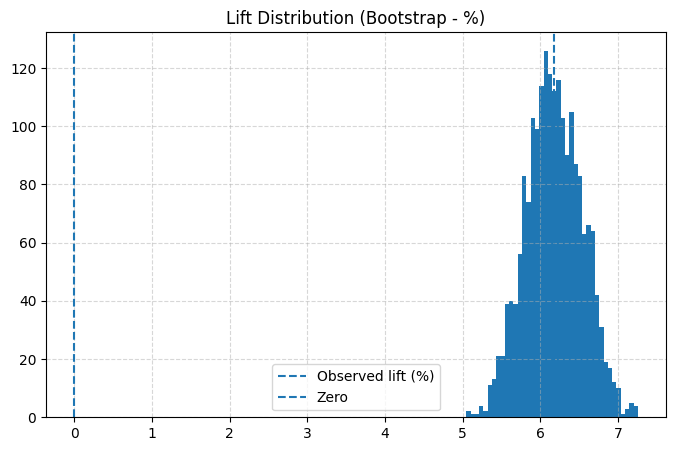


=== GEO PLACEBO TESTS (Cluster 2) ===
Number of placebo tests: 10
Average placebo lift (noise): -0.0189
Observed treatment lift: 3.9435
P-value (placebo): 0.0000
✔ High confidence: Observed lift is significantly higher than random placebos.


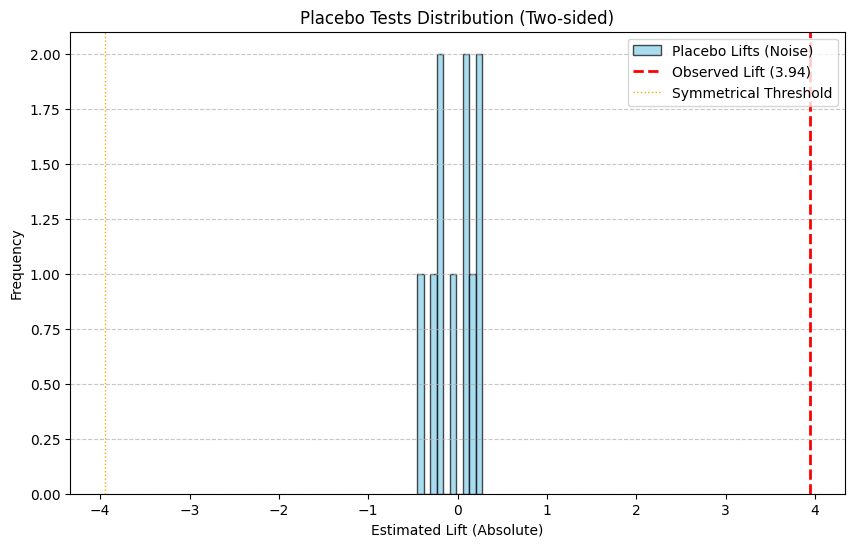


=== GEO SYNTHETIC CONTROL (Cluster 3) ===

Weights:
geo_3: 0.1696
geo_7: 0.5951
geo_11: 0.1656
geo_16: 0.0185
geo_21: 0.0511

Treatment period:
Start: 2025-04-01
End: 2025-05-06
Duration: 36 days

Mean lift (abs): 3.87
Mean lift (%): 7.43 %
Total lift: 139.48

=== SIGNIFICANCE (Cluster 3) ===

T-Test:
t-stat: 13.507
p-value: 0.0000

=== BOOTSTRAP TESTS SUMMARY (Cluster 3) ===
Total lift (abs): 139.48
95% CI (abs): [119.72, 160.10]
Total lift (%): 7.45%
95% CI (%): [6.43%, 8.52%]
p-value (bootstrap): 0.0000
✔ Lift statistically significant (CI does not cross 0)


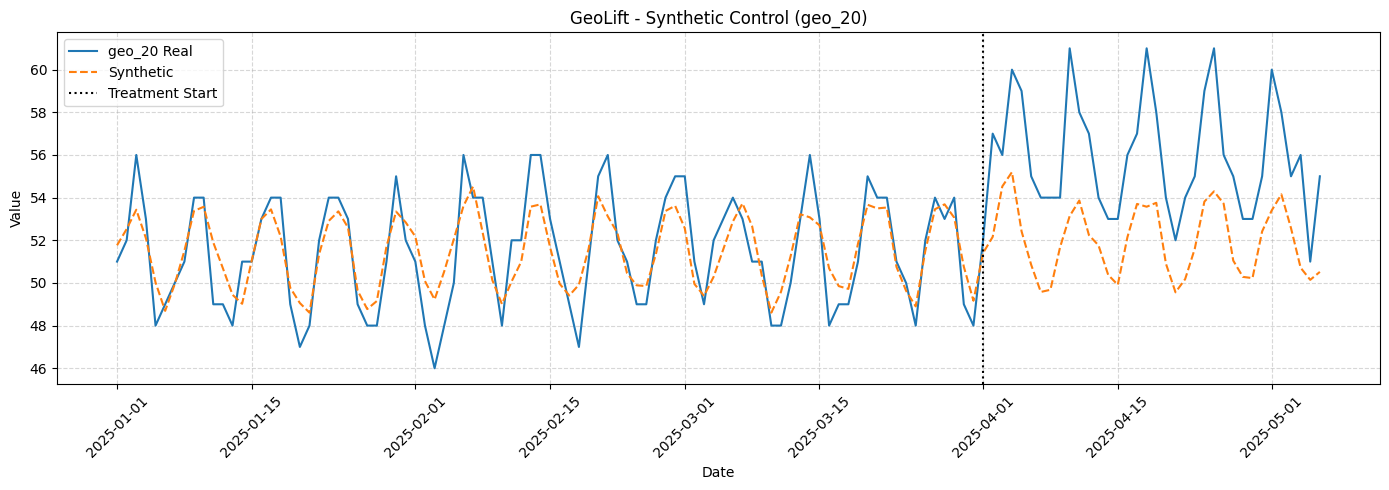

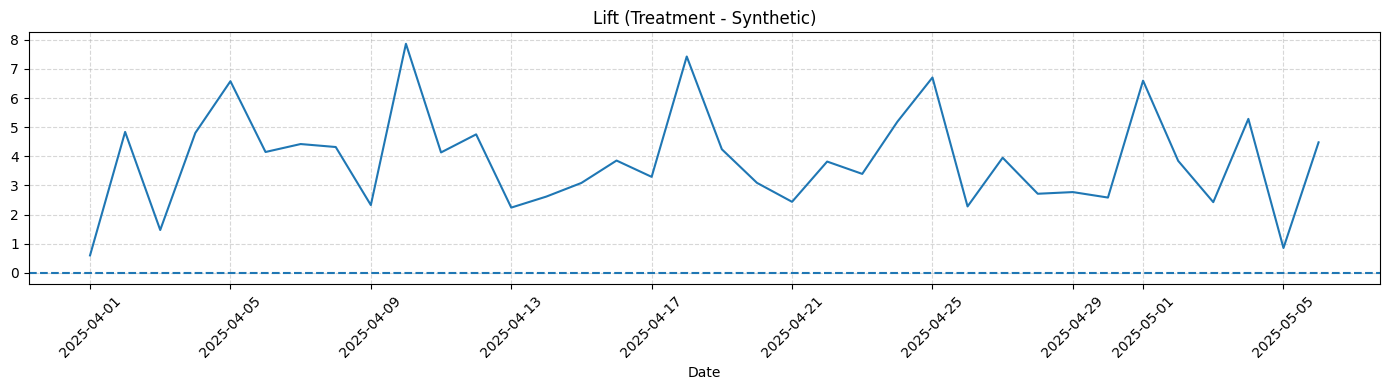

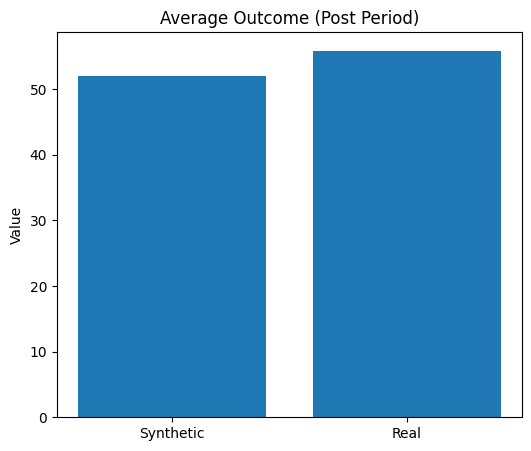

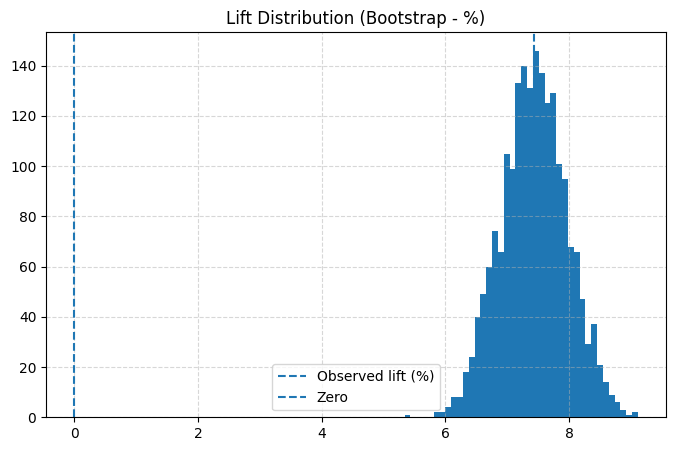


=== GEO PLACEBO TESTS (Cluster 3) ===
Number of placebo tests: 5
Average placebo lift (noise): -0.0423
Observed treatment lift: 3.8743
P-value (placebo): 0.0000
✔ High confidence: Observed lift is significantly higher than random placebos.


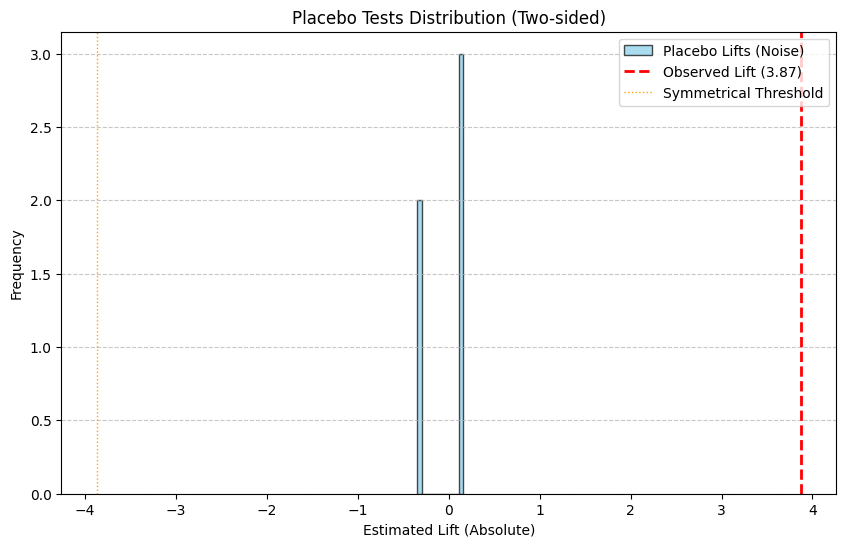


=== GEO SYNTHETIC CONTROL (Cluster 4) ===

Weights:
geo_7: 0.0324
geo_11: 0.2510
geo_13: 0.2015
geo_16: 0.1661
geo_19: 0.0682
geo_21: 0.0487
geo_24: 0.2321

Treatment period:
Start: 2025-04-01
End: 2025-05-06
Duration: 36 days

Mean lift (abs): 3.41
Mean lift (%): 5.19 %
Total lift: 122.81

=== SIGNIFICANCE (Cluster 4) ===

T-Test:
t-stat: 9.977
p-value: 0.0000

=== BOOTSTRAP TESTS SUMMARY (Cluster 4) ===
Total lift (abs): 122.81
95% CI (abs): [99.39, 146.53]
Total lift (%): 5.23%
95% CI (%): [4.27%, 6.21%]
p-value (bootstrap): 0.0000
✔ Lift statistically significant (CI does not cross 0)


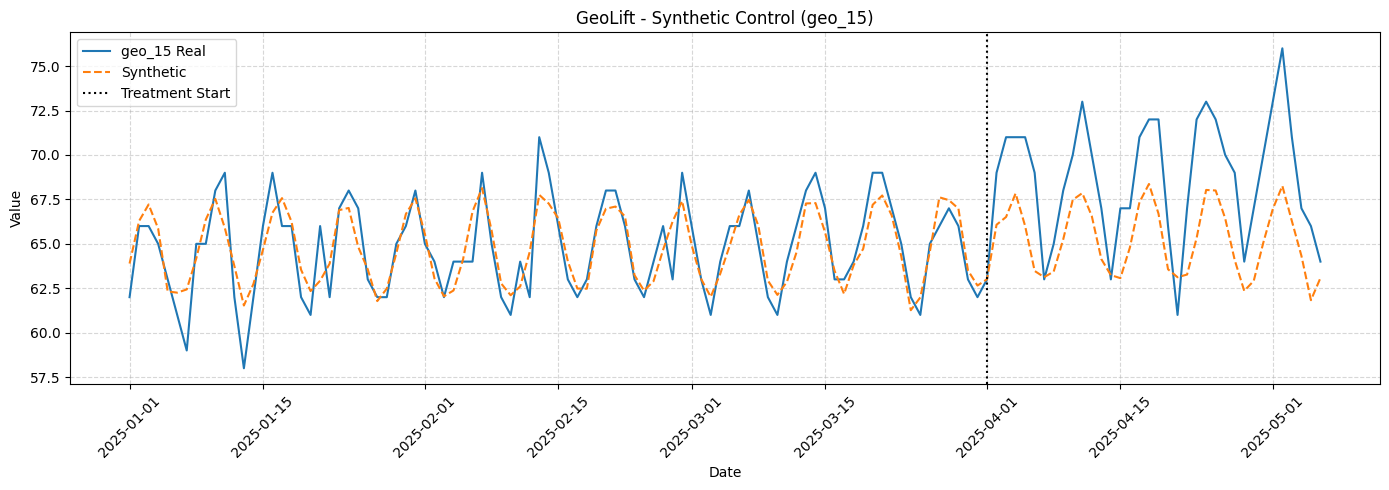

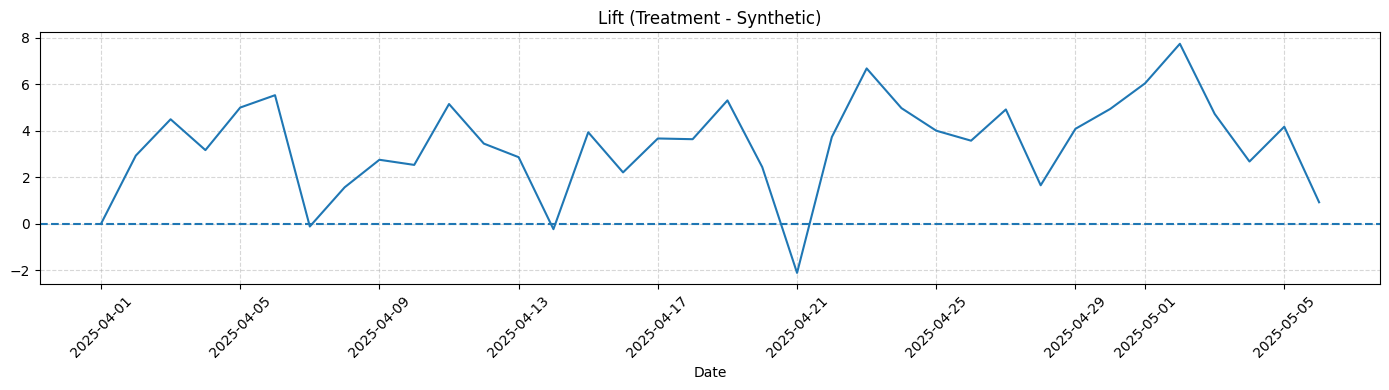

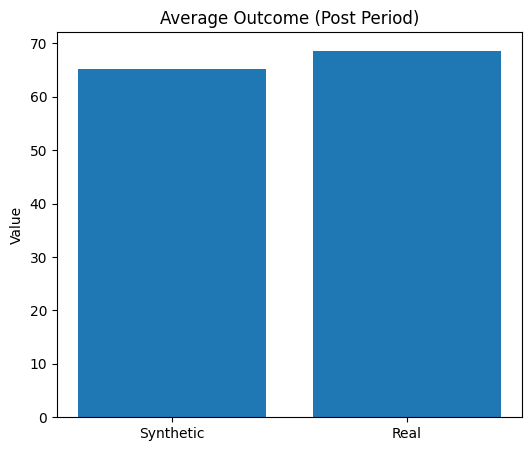

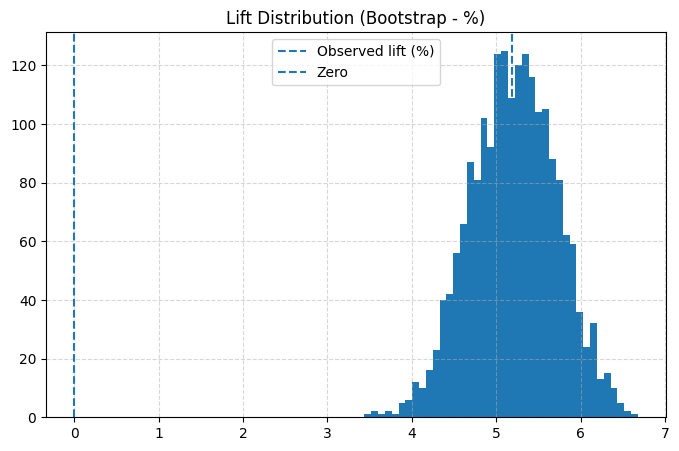


=== GEO PLACEBO TESTS (Cluster 4) ===
Number of placebo tests: 7
Average placebo lift (noise): -0.0564
Observed treatment lift: 3.4113
P-value (placebo): 0.0000
✔ High confidence: Observed lift is significantly higher than random placebos.


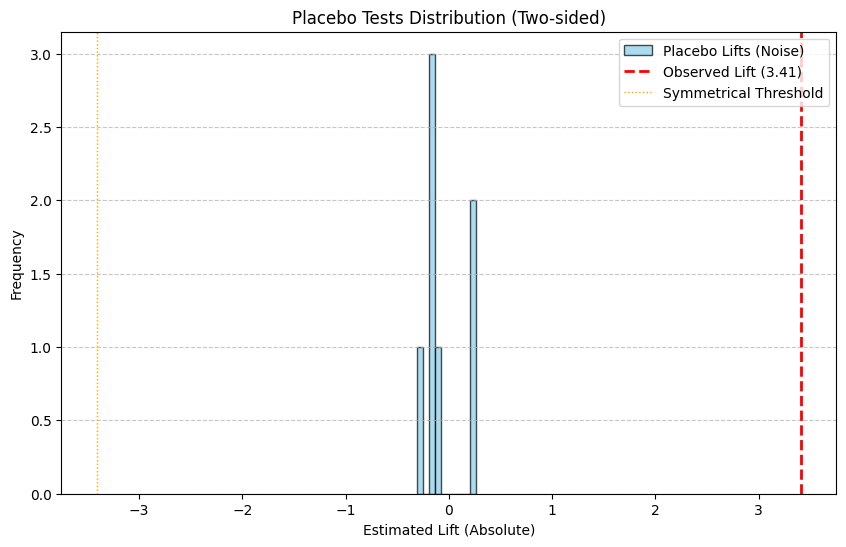

In [8]:
from reallift.geo.synthetic import run_synthetic_control
from reallift.geo.placebo import run_placebo_tests

for i, cluster in enumerate(clusters):
    synthetic = run_synthetic_control(
        filepath=file_post_test,
        date_col='date',
        treatment_geo=cluster["treatment"],
        control_geos=cluster["control"],
        treatment_start_date=treatment_start,
        random_state=42,
        cluster_idx=i,
        plot=True,
        verbose=True
    )
    
    placebo = run_placebo_tests(
        filepath=file_post_test,
        date_col='date',
        control_geos=cluster["control"],
        treatment_start_date=treatment_start,
        observed_lift=synthetic["lift_mean_abs"],
        random_state=42,
        cluster_idx=i,
        plot=True,
        verbose=True
    )